---
# <div align="center"><font color='green'> COSC 2673/2793 |  Machine Learning | Assignment 2 </font></div>
## <div align="center"> <font color='green'> Project 1: Classify Images of Colon Cancer       </font></div>
## <div align="center"> <font color='red'> Student Name: Doan Phan Thuy Trang | Pham Dung Minh Nhan                               </font></div>
## <div align="center"> <font color='red'> Student number: s4027648 | s3975793       </font></div>
---

# Problem statement

In this project, we aim to develop an end-to-end machine learning system to tackle a real-world medical image classification task. The dataset contains labeled 27x27 RGB histopathology images of colon cells, and our goal is to accurately predict two types of labels: whether a cell is cancerous and its specific cell type. The challenge involves selecting appropriate models, processing high-dimensional image data, evaluating model performance using reliable metrics, and making a justified final model choice through comparative analysis. This project includes two core tasks:

- Task 1: Train and optimize models to classify cancer presence and cell type using the main dataset.

- Task 2: Use additional data to improve the cell-type classification model and justify the final model selection based on performance.

# Data Exploration and Understanding

In [1]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import random

# Import the dataset
mainData = pd.read_csv('data/data_labels_mainData.csv') # Main data
extraData = pd.read_csv('data/data_labels_extraData.csv') # Extra data


## Data Cleaning

In this section, data shape, data types, and the first few records were inspected to confirm structure and content. In addition, unique values were analysed to detect inconsistencies. As a result, in Main Data, it was recognised that the cellType and cellTypeName columns have the same total count for each unique value, meaning they represent the same information, which is the name of the cell type. Keeping both columns would cause data leakage. Therefore, this issue will be addressed in the Prevention of Data Leakage section. Besides, the dataset was checked for missing values and duplicate records in CSV files, and no issues were found that require concern.

### Main data (data labels mainData.csv)

In [2]:
# Show the shape of the dataset (main data)
print("Shape of the dataset (main data):", mainData.shape) 

# Show the first few records of the dataset (main data)
print("\nFirst few records (main data):")
mainData.head()

Shape of the dataset (main data): (9896, 6)

First few records (main data):


,InstanceID,patientID,ImageName,cellTypeName,cellType,isCancerous
0,22405,1,22405.png,fibroblast,0,0
1,22406,1,22406.png,fibroblast,0,0
2,22407,1,22407.png,fibroblast,0,0
3,22408,1,22408.png,fibroblast,0,0
4,22409,1,22409.png,fibroblast,0,0


In [3]:
# Check information about the dataset and data types (main data)
print("\nInformation about the dataset (main data):")
mainData.info()


Information about the dataset (main data):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9896 entries, 0 to 9895
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   InstanceID    9896 non-null   int64 
 1   patientID     9896 non-null   int64 
 2   ImageName     9896 non-null   object
 3   cellTypeName  9896 non-null   object
 4   cellType      9896 non-null   int64 
 5   isCancerous   9896 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 464.0+ KB


In [4]:
# Check unique values in each numerical column (main data)
for column in mainData.select_dtypes(include='number').columns:
    print(f"Value counts for {column}:")
    print(mainData[column].value_counts().sort_index())
    print("\n" + "-"*50 + "\n")

Value counts for InstanceID:
InstanceID
1        1
2        1
3        1
4        1
5        1
        ..
22438    1
22439    1
22442    1
22443    1
22444    1
Name: count, Length: 9896, dtype: int64

--------------------------------------------------

Value counts for patientID:
patientID
1      19
2      33
3     136
4     127
5     169
6     198
7     253
8     332
9     348
10    302
11     56
12    130
13    180
14    207
15    125
16    111
17    310
18    320
19    158
20    325
21    224
22    152
23    254
24    192
25    180
26    157
27     17
28     15
29    355
30    110
31    137
32     99
33    163
34     14
35     11
36    128
37     71
38     84
39    105
40    209
41    250
42    136
43    137
44    121
45     74
46    120
47    133
48    147
49    187
50    195
51    286
52    178
53    132
54    389
55    263
56     92
57    149
58    161
59    115
60    115
Name: count, dtype: int64

--------------------------------------------------

Value counts for cellType:
ce

In [5]:
# Check unique values in each object column (main data)
for column in mainData.select_dtypes(include='object').columns:
    print(f"Value counts for {column}:")
    print(mainData[column].value_counts().sort_index())
    print("\n" + "-"*50 + "\n")

Value counts for ImageName:
ImageName
1.png        1
10.png       1
100.png      1
1000.png     1
10000.png    1
            ..
9995.png     1
9996.png     1
9997.png     1
9998.png     1
9999.png     1
Name: count, Length: 9896, dtype: int64

--------------------------------------------------

Value counts for cellTypeName:
cellTypeName
epithelial      4079
fibroblast      1888
inflammatory    2543
others          1386
Name: count, dtype: int64

--------------------------------------------------



In [6]:
# Check for missing values in the dataset (main data)
print("Missing values in the dataset (main data):")
print(mainData.isnull().sum())

# Check for duplicates in the dataset (main data)
print("\nDuplicates in the dataset (main data):")
print(mainData.duplicated().sum())

Missing values in the dataset (main data):
InstanceID      0
patientID       0
ImageName       0
cellTypeName    0
cellType        0
isCancerous     0
dtype: int64

Duplicates in the dataset (main data):
0


### Extra data (data labels extraData.csv)

In [7]:
# Show the shape of the dataset (extra data)
print("Shape of the dataset (extra data):", extraData.shape) 

# Show the first few records of the dataset (extra data)
print("\nFirst few records (extra data):")
extraData.head()

Shape of the dataset (extra data): (10384, 4)

First few records (extra data):


,InstanceID,patientID,ImageName,isCancerous
0,12681,61,12681.png,0
1,12682,61,12682.png,0
2,12683,61,12683.png,0
3,12684,61,12684.png,0
4,12685,61,12685.png,0


In [8]:
# Check information about the dataset and data types (extra data)
print("\nInformation about the dataset (extra data):")
extraData.info()


Information about the dataset (extra data):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10384 entries, 0 to 10383
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   InstanceID   10384 non-null  int64 
 1   patientID    10384 non-null  int64 
 2   ImageName    10384 non-null  object
 3   isCancerous  10384 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 324.6+ KB


In [9]:
# Check unique values in each numerical column (extra data)
for column in extraData.select_dtypes(include='number').columns:
    print(f"Value counts for {column}:")
    print(extraData[column].value_counts().sort_index())
    print("\n" + "-"*50 + "\n")

Value counts for InstanceID:
InstanceID
1631     1
1632     1
1633     1
1634     1
1635     1
        ..
22231    1
22232    1
22233    1
22234    1
22235    1
Name: count, Length: 10384, dtype: int64

--------------------------------------------------

Value counts for patientID:
patientID
61    114
62     93
63     45
64     86
65    326
66    376
67    369
68    422
69    337
70    199
71    290
72     91
73     12
74      8
75     12
77    696
78    409
79    699
80    507
81    365
82    213
83    339
84    316
85    405
86    360
87    342
88    374
89    480
90    416
91    642
92    571
93     78
94     32
95     27
96      6
97    166
98     86
99     75
Name: count, dtype: int64

--------------------------------------------------

Value counts for isCancerous:
isCancerous
0    7394
1    2990
Name: count, dtype: int64

--------------------------------------------------



In [10]:
# Check unique values in each object column (extra data)
for column in extraData.select_dtypes(include='object').columns:
    print(f"Value counts for {column}:")
    print(extraData[column].value_counts().sort_index())
    print("\n" + "-"*50 + "\n")

Value counts for ImageName:
ImageName
10246.png    1
10247.png    1
10248.png    1
10249.png    1
10250.png    1
            ..
9888.png     1
9889.png     1
9890.png     1
9891.png     1
9892.png     1
Name: count, Length: 10384, dtype: int64

--------------------------------------------------



In [11]:
# Check for missing values in the dataset (extra data)
print("Missing values in the dataset (extra data):")
print(extraData.isnull().sum())

# Check for duplicates in the dataset (extra data)
print("\nDuplicates in the dataset (extra data):")
print(extraData.duplicated().sum())

Missing values in the dataset (extra data):
InstanceID     0
patientID      0
ImageName      0
isCancerous    0
dtype: int64

Duplicates in the dataset (extra data):
0


# Dataset Description

The dataset contains 27×27 RGB images of colon cells from 99 patients, split into two CSV files: data_labels_mainData.csv and data_labels_extraData.csv. mainData includes both isCancerous and cellType labels for 60 patients, while extraData includes only isCancerous labels for the remaining 39. These labeled images are used for two classification tasks: detecting cancer presence and identifying specific cell types.

# Task 1:  Detect the presence of cancer in cell images

We preprocess the data by dropping the cellType and cellTypeName columns from the main dataset, then merging it with the extra dataset to increase the number of labeled records. This enhances the dataset and improves the model’s ability to make accurate predictions. Multiple classification models are trained, and the best-performing model is selected and evaluated on a test set to classify whether an image shows cancerous or non-cancerous cells.

## Construct the Data

In [12]:
# Drop the 'cellType' and 'cellTypeName' column from the main data
dataTask1 = mainData.drop(columns=['cellType', 'cellTypeName'])

# Merge the main data with the extra data
dataTask1 = pd.concat([dataTask1, extraData], ignore_index=True)

# Show the shape of the merged dataset
print("Shape of the merged dataset:", dataTask1.shape)

# Check for missing values in the merged dataset
print("\nMissing values in the merged dataset:")
print(dataTask1.isnull().sum())

# Check for duplicates in the merged dataset
print("\nDuplicates in the merged dataset:")
print(dataTask1.duplicated().sum())

# Show the first few records of the merged dataset
print("\nFirst few records of the merged dataset:")
dataTask1.head()


Shape of the merged dataset: (20280, 4)

Missing values in the merged dataset:
InstanceID     0
patientID      0
ImageName      0
isCancerous    0
dtype: int64

Duplicates in the merged dataset:
0

First few records of the merged dataset:


,InstanceID,patientID,ImageName,isCancerous
0,22405,1,22405.png,0
1,22406,1,22406.png,0
2,22407,1,22407.png,0
3,22408,1,22408.png,0
4,22409,1,22409.png,0


=> Based on the shape, since mainData has 9896 records and extraData has 10384 records, the merged dataset contains 20280 records, with no duplicates or missing values.

In [13]:
# Path to the images directory 
image_dir = 'data/patch_images/' 

# Function to return the full image path
def get_image_path(image_name):
    image_path = os.path.join(image_dir, image_name)  # Construct the full path
    if not os.path.exists(image_path):  # Check if the image exists
        print(f"Warning: Image {image_name} not found in {image_dir}") #
        return None  # Return None if the image does not exist
    return image_path

# Add a new column 'ImagePath' with the full image paths
dataTask1['ImagePath'] = dataTask1['ImageName'].apply(get_image_path)

# Display the first few rows to check the new column
dataTask1.head()

,InstanceID,patientID,ImageName,isCancerous,ImagePath
0,22405,1,22405.png,0,data/patch_images/22405.png
1,22406,1,22406.png,0,data/patch_images/22406.png
2,22407,1,22407.png,0,data/patch_images/22407.png
3,22408,1,22408.png,0,data/patch_images/22408.png
4,22409,1,22409.png,0,data/patch_images/22409.png


The dataset was constructed by merging mainData and extraData after dropping the cellType and cellTypeName columns from mainData. Image paths were then appended to each record to enable efficient access during model training. This merged dataset is used for Task 1.

## Split the Data

The dataset is split into 80% training (used to train the model), 10% validation (used for hyperparameter tuning), and 10% test (used for final evaluation). This setup ensures fair evaluation and helps prevent information leakage between training and testing phases. The 80/10/10 split is commonly used in machine learning as it strikes a balance between having enough data to train effectively and ensuring reliable evaluation, especially when the dataset is moderately sized.

In [14]:
from sklearn.model_selection import train_test_split

# First, split into train (80%) and temp (20%)
trainData, temptData = train_test_split(
    dataTask1,
    test_size=0.2,
    stratify=dataTask1['isCancerous'],
    random_state=42
)

# Then split temp into validation (10%) and test (10%)
validationData, testData = train_test_split(
    temptData,
    test_size=0.5,
    stratify=temptData['isCancerous'],
    random_state=42
)

# Print dataset sizes
print("Number of instances in the original dataset is {}. After splitting, Train has {}, Validation has {}, and Test has {} instances."
      .format(dataTask1.shape[0], trainData.shape[0], validationData.shape[0], testData.shape[0]))

Number of instances in the original dataset is 20280. After splitting, Train has 16224, Validation has 2028, and Test has 2028 instances.


### Class Imbalance Identification

To assess class balance in the dataset, we counted the number of cancerous (isCancerous = 1) and non-cancerous (isCancerous = 0) images. The dataset contains:

- Train Set:
    - Non-Cancerous: 10,569 samples
    - Cancerous: 5,655 samples
- Validation Set:
    - Non-Cancerous: 1,321 samples
    - Cancerous: 707 samples
- Test Set:
    - Non-Cancerous: 1,321 samples
    - Cancerous: 707 samples

This indicates a class imbalance, with non-cancerous samples being nearly twice as prevalent as cancerous ones. Such an imbalance can lead to models being biased towards the majority class, potentially limiting their ability to accurately identify cancerous cases. Addressing this imbalance through techniques like augmentation or resampling is essential for developing machine learning models that are both fair and effective, ensuring they generalize well across both cancerous and non-cancerous cell types.

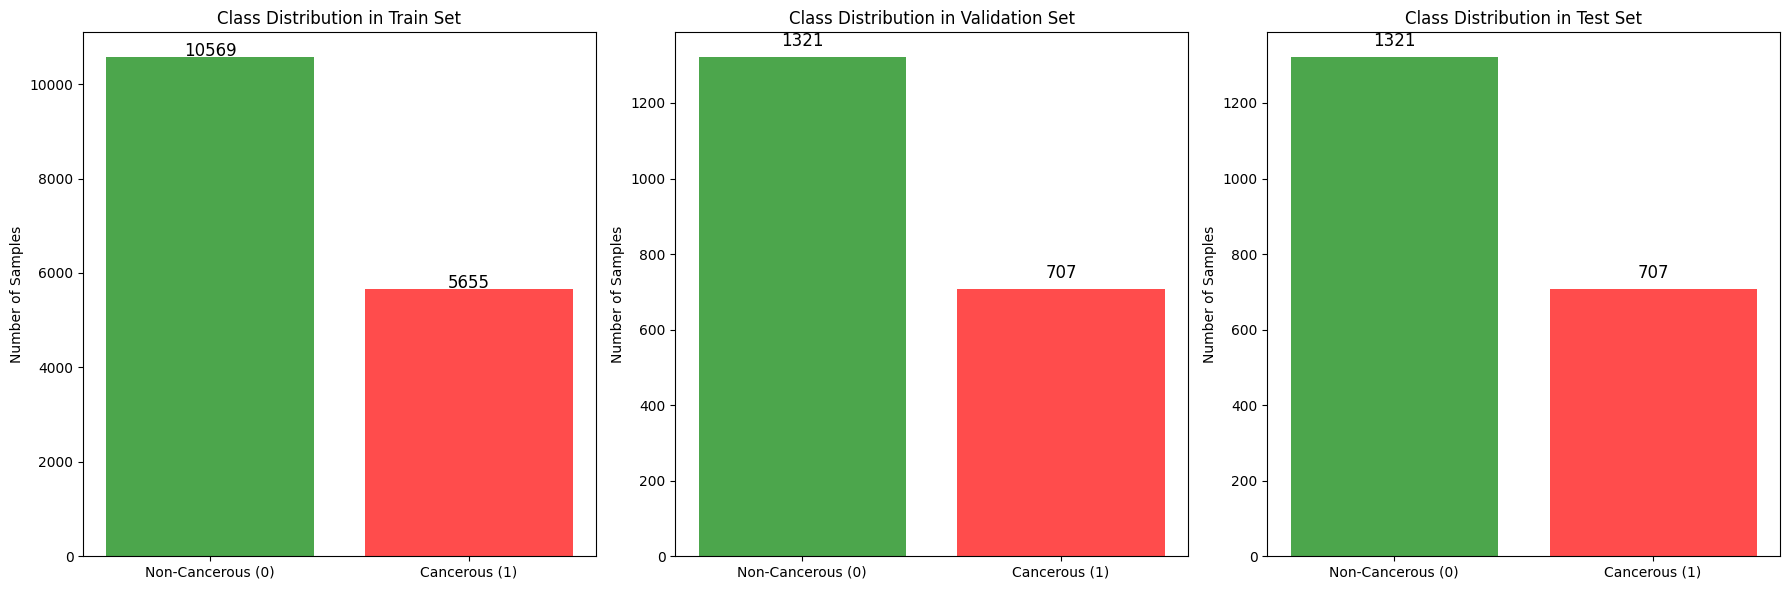

In [15]:
# Function to plot class distribution with value labels on top of bars
def plot_class_distribution(data, split_name, ax):
    countData = data['isCancerous'].value_counts()
    
    # Plot bars with colors: Green for Non-Cancerous (0), Red for Cancerous (1)
    ax.bar(0, countData.get(0, 0), alpha=0.7, color='green', label='Non-Cancerous (0)')
    ax.bar(1, countData.get(1, 0), alpha=0.7, color='red', label='Cancerous (1)')
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Non-Cancerous (0)', 'Cancerous (1)'])
    ax.set_ylabel('Number of Samples')
    ax.set_title(f'Class Distribution in {split_name} Set')

    # Add value labels on top of the bars
    for i, count in enumerate([countData.get(0, 0), countData.get(1, 0)]):
        ax.text(i, count + 30, str(count), ha='center', fontsize=12)

# Plot distributions for each split
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Train data distribution
plot_class_distribution(trainData, 'Train', axs[0])

# Validation data distribution
plot_class_distribution(validationData, 'Validation', axs[1])

# Test data distribution
plot_class_distribution(testData, 'Test', axs[2])

# Adjust layout
plt.tight_layout()
plt.show()

## Data Augmentation and Transformation

To address the class imbalance in the dataset, we focused on augmenting only the cancerous cell images in the training set. Augmentation techniques such as rotation, zoom, width and height shifts, and horizontal flips were applied to generate new, synthetic images. These augmented samples were then added to the original training data, resulting in a more balanced class distribution between cancerous and non-cancerous cases. By doing so, the model is less likely to become biased toward the non-cancerous class and can more effectively detect cancerous instances, ultimately improving its overall performance and generalisation.

Number of augmented images generated: 4914


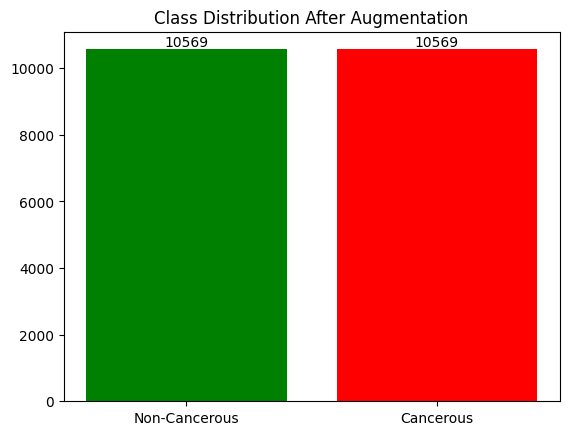

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the augmentation
augmentor = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Extract cancerous samples from trainData
cancerous_data = trainData[trainData['isCancerous'] == 1]
non_cancerous_count = trainData[trainData['isCancerous'] == 0].shape[0]
cancerous_count = cancerous_data.shape[0]

# Number of images to generate
n_to_generate = non_cancerous_count - cancerous_count

# Collect images as a numpy array
cancerous_images = np.array([cv2.imread(image_path) for image_path in cancerous_data['ImagePath']])

# Ensure InstanceID and ImageName columns are strings
trainData['InstanceID'] = trainData['InstanceID'].astype(str)
trainData['ImageName'] = trainData['ImageName'].astype(str)

# Get the current largest InstanceID from the dataset
existing_instance_ids = trainData['InstanceID'].str.extract(r'(\d+)').astype(int)
max_instance_id = existing_instance_ids.max()[0] if not existing_instance_ids.empty else 0

# Get the current largest ImageName number from the dataset
existing_image_names = trainData['ImageName'].str.extract(r'(\d+)').astype(int)
max_image_name = existing_image_names.max()[0] if not existing_image_names.empty else 0

# Use flow to generate augmented images
augmented_images = []
augmented_labels = []
augmented_instance_ids = []
augmented_patient_ids = []
augmented_image_names = []
augmented_image_paths = []

# Track the current max values for augmentation
current_max_instance_id = max_instance_id
current_max_image_name = max_image_name

for batch in augmentor.flow(cancerous_images, batch_size=32, shuffle=False):
    for i, img in enumerate(batch):
        augmented_images.append(img)
        augmented_labels.append(1)  # All augmented images are cancerous
        
        # Increment InstanceID and ImageName dynamically
        current_max_instance_id += 1
        current_max_image_name += 1
        
        augmented_instance_ids.append(f"aug_{current_max_instance_id}")
        augmented_patient_ids.append(cancerous_data.iloc[i % cancerous_data.shape[0]]['patientID'])  # Copy patientID from original data
        augmented_image_names.append(f"aug_{current_max_image_name}.png")  # Increment image names
        augmented_image_paths.append("generated_in_memory")  # Placeholder for image path
        
        if len(augmented_images) >= n_to_generate:
            break
    if len(augmented_images) >= n_to_generate:
        break

# Create temp DataFrame for augmented images
augmented_df = pd.DataFrame({
    'InstanceID': augmented_instance_ids,
    'patientID': augmented_patient_ids,
    'ImageName': augmented_image_names,
    'isCancerous': augmented_labels,
    'ImagePath': augmented_image_paths  
})

# Combine with original trainData
trainData = pd.concat([trainData, augmented_df], ignore_index=True)

# Print how many augmentations were made
print(f"Number of augmented images generated: {len(augmented_images)}")

# Plot the class distribution after augmentation
classCount = trainData['isCancerous'].value_counts()

plt.bar(classCount.index, classCount.values, color=['green', 'red'])
plt.xticks([0, 1], ['Non-Cancerous', 'Cancerous'])
plt.title('Class Distribution After Augmentation')
for i, v in enumerate(classCount.values):
    plt.text(i, v + 100, str(v), ha='center')
plt.show()


In [17]:
# Check the shape of the final trainData
print("\nShape of the final trainData:")
print(trainData.shape)

# Check for missing values in the dataset
print("\nMissing values in the dataset:")
print(trainData.isnull().sum())

# Check for duplicates in the  dataset
print("\nDuplicates in the dataset:")
print(trainData.duplicated().sum())


Shape of the final trainData:
(21138, 5)

Missing values in the dataset:
InstanceID     0
patientID      0
ImageName      0
isCancerous    0
ImagePath      0
dtype: int64

Duplicates in the dataset:
0


## Exploratory Data Analysis (EDA)

In this section, we conduct final analyses to better understand the dataset's structure, uncover hidden patterns, detect anomalies, and ensure the dataset is ready for model training. We focus on key aspects such as image size consistency, identifying any potential issues, and visualizing random samples to gain further insights.

### Image Size Distribution

This section ensures that all images are 27x27 pixels. Any deviations in image dimensions are flagged to maintain uniformity, preventing potential issues during model training.

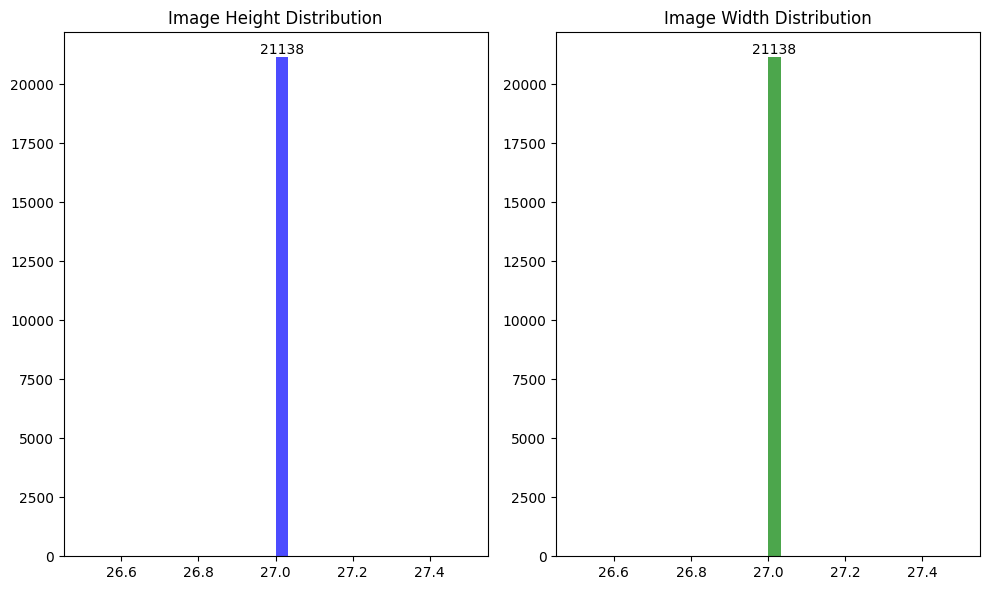

Number of images with incorrect size: 0


In [18]:
# Check dimensions of images (including augmented images)
image_sizes = []

# Loop through the entire trainData and check dimensions
augmented_idx = 0  # Keep track of the index for augmented images
for idx, row in trainData.iterrows():
    image_path = row['ImagePath']
    
    # If the image is augmented (generated in memory), use augmented_images list
    if image_path != "generated_in_memory":
        # Read image from the original path
        img = cv2.imread(image_path)
        if img is not None:
            image_sizes.append(img.shape[:2])  # Only take height and width (ignore channels)
        else:
            print(f"Warning: Unable to read image at path {image_path}")
    else:
        # For augmented images, use their dimensions directly
        if augmented_idx < len(augmented_images):
            img = augmented_images[augmented_idx]  # Get the augmented image from the list
            if img is not None:
                image_sizes.append(img.shape[:2])
            else:
                print(f"Warning: Augmented image at index {augmented_idx} is None")
            augmented_idx += 1  # Increment the index for augmented images
        else:
            print(f"Warning: No corresponding augmented image for augmented entry at index {idx}")

# Convert to DataFrame for easier manipulation
image_sizes_df = pd.DataFrame(image_sizes, columns=['Height', 'Width'])

# Set the number of bins for histograms
num_bins = 30  # You can adjust this based on the distribution

# Plot the distribution of image dimensions
plt.figure(figsize=(10, 6))

# Plot Height Distribution
plt.subplot(1, 2, 1)
n, bins, patches = plt.hist(image_sizes_df['Height'], bins=num_bins, color='blue', alpha=0.7)
plt.title('Image Height Distribution')

# Add value labels on bars
for i in range(len(patches)):
    if n[i] > 0:  # Only add labels to bars with non-zero counts
        height = n[i]
        plt.text(patches[i].get_x() + patches[i].get_width() / 2,
                 height + 10,  # Place the text above the bar
                 str(int(height)),
                 ha='center', va='bottom')

# Plot Width Distribution
plt.subplot(1, 2, 2)
n, bins, patches = plt.hist(image_sizes_df['Width'], bins=num_bins, color='green', alpha=0.7)
plt.title('Image Width Distribution')

# Add value labels on bars
for i in range(len(patches)):
    if n[i] > 0:  # Only add labels to bars with non-zero counts
        width = n[i]
        plt.text(patches[i].get_x() + patches[i].get_width() / 2,
                 width + 10,  # Place the text above the bar
                 str(int(width)),
                 ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Check if there are any mismatched image sizes (both original and augmented images)
incorrect_sizes = image_sizes_df[(image_sizes_df['Height'] != 27) | (image_sizes_df['Width'] != 27)]
print(f"Number of images with incorrect size: {len(incorrect_sizes)}")

=> All images are correctly sized at 27 x 27 pixels.

### Visualising Random Samples

Visualizing random images from both cancerous and non-cancerous classes is crucial for understanding the data distribution and variability within each class. This step provides valuable insights into the diversity of the samples and potential challenges for model training. However, since the images are small (27x27 pixels), enlarging them during display can cause distortion or blurriness, making it difficult to interpret fine details.

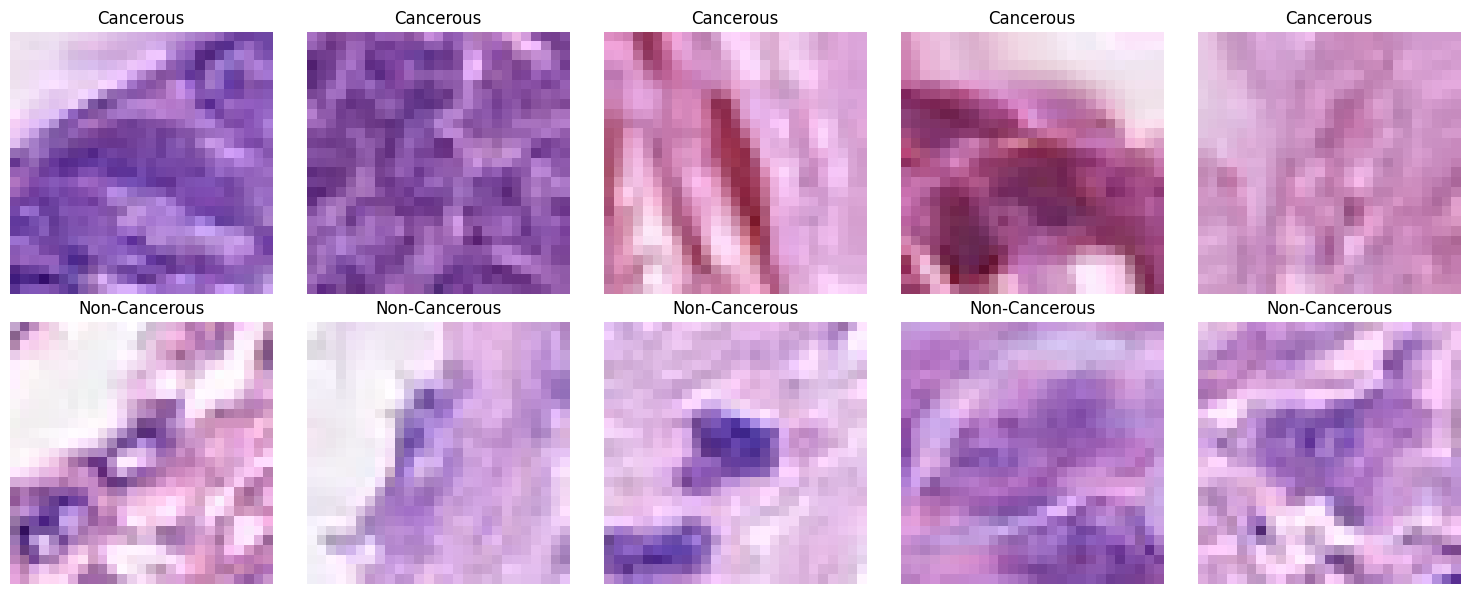

In [19]:
# Separate cancerous and non-cancerous images
cancerous_data = trainData[trainData['isCancerous'] == 1]
non_cancerous_data = trainData[trainData['isCancerous'] == 0]

# Select random samples from both classes (cancerous and non-cancerous)
random_cancerous_samples = random.sample(list(cancerous_data['ImagePath']), 5)  # Select 5 random samples
random_non_cancerous_samples = random.sample(list(non_cancerous_data['ImagePath']), 5)

# Function to process image and ensure it's within the correct range
def process_image(img):
    # Check if the image is in float format (normalized between 0 and 1)
    if img.max() <= 1.0:  # Float image (range [0, 1])
        img = img * 255  # Convert to [0, 255] range for display
    # Ensure image is within the valid range [0, 255]
    img = np.clip(img, 0, 255).astype(np.uint8)  # Convert to uint8 if it's float
    return img

# Create a subplot for displaying images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Display cancerous samples
for i, image_path in enumerate(random_cancerous_samples):
    # Check if the image is augmented or original
    if image_path == "generated_in_memory":
        img = augmented_images[i]  # Get the augmented image from the list
    else:
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB for proper display
    
    img = process_image(img)  # Process the image to ensure it's in the correct range
    
    # Display the image with exact size (27x27)
    axes[0, i].imshow(img)
    axes[0, i].axis('off')
    axes[0, i].set_title("Cancerous")
    axes[0, i].set_aspect('equal')  # Ensure the aspect ratio is equal to display correctly

# Display non-cancerous samples
for i, image_path in enumerate(random_non_cancerous_samples):
    # Check if the image is augmented or original
    if image_path == "generated_in_memory":
        img = augmented_images[i]  # Get the augmented image from the list
    else:
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB for proper display
    
    img = process_image(img)  # Process the image to ensure it's in the correct range
    
    # Display the image with exact size (27x27)
    axes[1, i].imshow(img)
    axes[1, i].axis('off')
    axes[1, i].set_title("Non-Cancerous")
    axes[1, i].set_aspect('equal')  # Ensure the aspect ratio is equal to display correctly

# Adjust layout for better appearance
plt.tight_layout()
plt.show()

## Performance Metrics Selection

For the binary classification task of detecting the presence of cancerous cells, several evaluation metrics will be used to assess model performance and predictive reliability: Accuracy, Confusion Matrix, Precision, Recall, F1-Score, and Cross-Validation Score.

- Accuracy: This metric measures the overall proportion of correctly predicted instances out of all predictions. It provides a general sense of how well the model performs. Although accuracy can be misleading in imbalanced datasets, this is not a concern here, as class imbalance has been addressed and the dataset is now balanced.

- Confusion Matrix: This metric presents the counts of true positives, true negatives, false positives, and false negatives, offering detailed insight into specific prediction outcomes and types of errors.

- Precision: This metric calculates the proportion of correctly identified positive cases among all predicted positives. It is particularly important when the cost of false positives is high.

- Recall: This metric evaluates the proportion of actual positive cases that were correctly identified, which is critical in medical contexts where missing a cancer diagnosis could be dangerous.

- F1-Score: This harmonic mean of precision and recall provides a balanced metric that is especially useful when both false positives and false negatives carry significant consequences.

- Cross-Validation Score: This method assesses model performance across multiple subsets of the data, offering a more robust estimate of generalizability and stability by reducing overfitting to a single train-test split.

## Base Model Selection

### Criteria

- Model Capacity: The model should have sufficient capacity to learn the complexity of the task but not be so complex that it overfits the data.
- Fine-tuning: Ensure the model can be fine-tuned to adapt to the specific dataset and task.
- Scalability: The model should be scalable to handle increasing data volumes and user requests.
- Adaptability: The model should be flexible enough to adapt to new data and evolving requirements.

### Comparision between models

For this binary image classification task with over 24000 images (27 x 27 pixels), Convolutional Neural Network (CNN) and Support Vector Machine (SVM) are chosen as base models.

#### Convolutional Neural Networks (CNN)
- Assumptions:
    * Input data has a grid-like structure (Such as images).
    * Spatially local patterns are important (Such as edges and textures).
    * Training data is representative of real-world inputs for effective generalisation.
- Limitations:
    * Requires more computational resources than traditional models.
    * Can overfit if the architecture is too complex or regularisation is weak.
    * Requires a larger amount of labelled data for best performance.
- Performance:
    * High performance on image-based tasks due to spatial feature learning.
    * Scales well with data size and complexity if properly designed.
    * Can achieve near state-of-the-art results in binary classification tasks.
#### Support Vector Machine (SVM)
- Assumptions:
    * Data is linearly or non-linearly separable with an appropriate kernel.
    * Each input feature vector is meaningful (Flattened image must retain discriminative information).
    * Only a subset of data (support vectors) determines the decision boundary.
- Limitations:
    * Losing spatial information when image data is flattened.
    * Not scaling well to extremely large datasets.
    * Choosing the right kernel and hyperparameters can be non-trivial.
- Performance:
    * Strong baseline for small to mid-sized image datasets.
    * Performs well when classes are separable and data is limited.
    * May underperform on complex patterns compared to CNN.

# Model Optimisation

write something here if needed

## Identification of Overfitting/Underfitting

write something here if needed

## Optimisation Techniques

write something here if needed

## Validation Set Use

write something here if needed

# Model Performance and Robustness

write something here if needed

## Final Model Accuracy

write something here if needed

## Robustness and Generalisability

write something here if needed

# Independent Evaluation

write something here if needed

## Comparative Analysis

write something here if needed

### Comparision with Baseline and Literature Models

write something here if needed

### Fairness and Consistency 

write something here if needed

## Critical Discussion

write something here if needed

### Insightful Discussion

write something here if needed

### Real-world Applicability

write something here if needed

# Conclusion

write conclusion here

🧠 Base Model Selection and Justification

We select two models for comparison: Convolutional Neural Networks (CNN) and Support Vector Machine (SVM) with feature extraction. These choices are grounded in our coursework and relevant to image classification tasks.

🔹 Model 1: Convolutional Neural Networks (CNN)
Justification:

Covered in Week 9 lecture and lab.

CNNs are specifically designed for spatial data like images.

They perform automated feature extraction using convolutional layers, eliminating the need for manual engineering.

CNNs are translation-invariant, meaning they can learn important spatial hierarchies such as edges, shapes, and textures.

As shown in CS231n materials and Week 9 notebook, CNNs have demonstrated state-of-the-art performance on datasets like CIFAR-10 (similar to ours).

Use of pooling, ReLU activation, and dropout provides regularization and stability in deep learning pipelines.

🔹 Model 2: Support Vector Machine (SVM) with PCA-reduced features
Justification:

Introduced in Weeks 4–5 and commonly used for high-dimensional data.

SVMs work well in small to medium-sized datasets and when classes are well-separated.

To handle the high dimensionality of image data, Principal Component Analysis (PCA) will be applied beforehand, as discussed in Week 7.

SVM with RBF kernel has been proven effective for non-linear decision boundaries.

This pipeline allows for interpretability and faster training compared to deep models, and acts as a strong baseline.

Conclusion:

CNN will serve as the primary model due to its ability to extract and learn deep visual patterns directly from images.

SVM with PCA will act as a benchmark model to assess whether traditional ML pipelines can compete with deep learning in our context.